In [183]:
import pandas as pd
import matplotlib.pyplot as plt

In [184]:
filepath = "data/gen9ou-0.txt"
#define filepath for future use

In [185]:
with open(filepath, 'r') as f:
    lines = f.readlines()

    data_lines = [line.strip() for line in lines if '|' in line and "Rank" 
    not in line and "---" not in line]
    #filters out where data actually begins

    #split by pipe
    rows = [line.split('|')[1:-1] for line in data_lines]
    rows = [[cell.strip() for cell in row] for row in rows]

    columns = ["Rank", "Pokemon", "Usage %", "Raw", "Raw %", "Real", "Real %"]

    stats_df = pd.DataFrame(rows, columns=columns)
    #df created

    #convert rows to numeric
    stats_df["Rank"] = stats_df["Rank"].astype(int)
    stats_df["Usage %"] = stats_df["Usage %"].str.replace('%', '').astype(float)
    stats_df["Raw"] = stats_df["Raw"].astype(int)
    stats_df["Raw %"] = stats_df["Raw %"].str.replace('%', '').astype(float)
    stats_df["Real"] = stats_df["Real"].astype(int)
    stats_df["Real %"] = stats_df["Real %"].str.replace('%', '').astype(float)



In [186]:
stats_df.head()

,Rank,Pokemon,Usage %,Raw,Raw %,Real,Real %
0,1,Great Tusk,28.68381,602878,28.684,479220,28.641
1,2,Kingambit,18.79622,395060,18.796,271084,16.201
2,3,Gholdengo,18.59330,390795,18.593,300632,17.967
3,4,Dragapult,14.95804,314389,14.958,246596,14.738
4,5,Dragonite,14.68347,308618,14.683,228337,13.647


In [187]:
stats_df = stats_df.set_index("Rank")
stats_df_cleaned = stats_df[['Pokemon', 'Usage %']]
stats_df_cleaned

#filter out only rank and usage stats. those are the only important things to me

,Pokemon,Usage %
Rank,,
1,Great Tusk,28.68381
2,Kingambit,18.79622
3,Gholdengo,18.59330
4,Dragapult,14.95804
5,Dragonite,14.68347
...,...,...
745,Pawmo,0.00005
746,Arrokuda,0.00005
747,Rockruff,0.00005


In [188]:
role_map = {
    "Great Tusk": "Hazard Removal",
    "Kingambit": "Sweeper",
    "Gholdengo": "Wallbreaker",
    "Dragapult": "Attacker",
    "Dragonite": "Sweeper",
    "Ogerpon-Wellspring": "Wallbreaker",
    "Iron Valiant": "Attacker",
    "Zamazenta": "Attacker",
    "Slowking-Galar": "Pivot",
    "Corviknight": "Pivot",
    "Gliscor": "Wall",
    "Raging Bolt": "Wallbreaker",
    "Hatterene": "Hazard Removal",
    "Landorus-Therian": "Pivot",
    "Cinderace": "Attacker",
    "Iron Treads": "Hazard Lead",
    "Alomomola": "Pivot",
    "Glimmora": "Hazard Lead",
    "Kyurem": "Wallbreaker",
    "Ceruledge": "Sweeper",
    "Samurott-Hisui": "Hazard Lead",
    "Scizor": "Pivot",
    "Ting-Lu": "Wall",
    "Darkrai": "Attacker",
    "Rillaboom": "Pivot",
    "Garganacl": "Wall",
    "Iron Moth": "Sweeper",
    "Zapdos": "Pivot",
    "Pecharunt": "Pivot",
    "Walking Wake": "Sun Sweeper",
    "Garchomp": "Hazard Stack",
    "Tyranitar": "Weather Setter",
    "Heatran": "Wallbreaker",
    "Primarina": "Pivot",
    "Clefable": "Pivot",
    "Moltres": "Pivot",
    "Enamorus": "Sweeper",
    "Deoxys-Speed": "Attacker",
    "Meowscarada": "Pivot",
    "Excadrill": "Sand Sweeper",
    "Weezing-Galar": "Pivot",
    "Iron Crown": "Pivot",
    "Torkoal": "Weather Setter",
    "Pelipper": "Weather Setter",
    "Dondozo": "Wall",
    "Toxapex": "Pivot",
    "Tornadus-Therian": "Pivot",
    "Hydrapple": "Wallbreaker",
    "Clodsire": "Wall",
    "Greninja": "Sweeper",
    "Blaziken": "Sweeper",
    "Ninetales-Alola": "Weather Setter",
    "Ursaluna": "Wallbreaker",
    "Serperior": "Sweeper",
    "Araquanid": "Hazard Lead",
    "Hoopa-Unbound": "Wallbreaker",
    "Blissey": "Wall",
    "Weavile": "Wallbreaker",
    "Ninetales": "Weather Setter",
    "Skeledirge": "Wall",
    "Lokix": "Wallbreaker",
    "Rotom-Wash": "Pivot",
    "Quaquaval": "Sweeper",
    "Latios": "Wallbreaker",
    "Sinistcha": "Utility",
    "Venusaur": "Sweeper",
    "Tinkaton": "Utility",
    "Grimmsnarl": "Utility",
    "Iron Hands": "Pivot",
    "Ribombee": "Hazard Lead",
    "Skarmory": "Wall",
    "Volcanion": "Wallbreaker",
    "Gengar": "Sweeper",
    "Goodra-Hisui": "Wall",
    "Barraskewda": "Sweeper",
    "Arcanine-Hisui": "Wallbreaker",
    "Mimikyu": "Sweeper",
    "Ogerpon-Cornerstone": "Sweeper",
    "Zoroark-Hisui": "Wallbreaker",
    "Hawlucha": "Sweeper",
    "Ogerpon": "Wallbreaker",
    "Umbreon": "Wall",
    "Keldeo": "Wallbreaker",
    "Metagross": "Wallbreaker",
    "Maushold": "Hazard Removal",
    "Polteageist": "Sweeper",
    "Iron Boulder": "Sweeper",
    "Incineroar": "Pivot",
    "Indeedee": "Utility",
    "Moltres-Galar": "Sweeper",
    "Slither Wing": "Wallbreaker",
    "Azumarill": "Wallbreaker",
    "Thundurus-Therian": "Sweeper",
    "Latias": "Sweeper",
    "Gyarados": "Sweeper",
    "Kommo-o": "Sweeper",
    "Hydreigon": "Wallbreaker",
    "Cresselia": "Wall",
    "Cloyster": "Sweeper",
    "Mandibuzz": "Pivot",
    "Comfey": "Sweeper",
    "Galvantula": "Hazard Lead",
    "Lilligant-Hisui": "Sweeper",
    "Gardevoir": "Wallbreaker",
    "Conkeldurr": "Wallbreaker",
    "Charizard": "Sweeper",
    "Talonflame": "Pivot",
    "Haxorus": "Sweeper",
    "Chesnaught": "Hazard Stack",
    "Blastoise": "Hazard Removal",
    "Jolteon": "Pivot",
    "Salamence": "Sweeper",
    "Kingdra": "Sweeper",
    "Mamoswine": "Wallbreaker",
    "Espeon": "Utility",
    "Okidogi": "Wallbreaker",
    "Milotic": "Wall",
    "Sandy Shocks": "Hazard Stack",
    "Magnezone": "Wallbreaker",
    "Manaphy": "Sweeper",
    "Amoonguss": "Wall",
    "Chandelure": "Wallbreaker",
    "Kleavor": "Hazard Lead",
    "Forretress": "Hazard Removal",
    "Armarouge": "Wallbreaker",
    "Jirachi": "Pivot",
    "Bronzong": "Wall",
    "Ditto": "Utility",
    "Toxicroak": "Sweeper",
    "Empoleon": "Hazard Removal",
    "Lucario": "Sweeper",
    "Infernape": "Pivot",
    "Whimsicott": "Utility",
    "Mew": "Utility",
    "Slowking": "Pivot",
    "Fezandipiti": "Pivot",
    "Muk-Alola": "Wall",
    "Snorlax": "Wall",
    "Chansey": "Wall",
    "Pawmot": "Wallbreaker",
    "Swampert": "Pivot",
    "Gastrodon": "Wall",
    "Reuniclus": "Sweeper",
    "Breloom": "Wallbreaker",
    "Salazzle": "Sweeper",
    "Gallade": "Sweeper",
    "Porygon2": "Wall",
    "Porygon-Z": "Sweeper",
    "Tentacruel": "Hazard Removal",
    "Sylveon": "Wall",
    "Hippowdon": "Weather Setter",
    "Regidrago": "Wallbreaker",
    "Krookodile": "Pivot",
    "Torterra": "Sweeper",
    "Zapdos-Galar": "Sweeper",
    "Sableye": "Utility",
    "Deoxys-Defense": "Hazard Lead",
    "Crawdaunt": "Wallbreaker",
    "Quagsire": "Wall",
    "Vaporeon": "Wall",
    "Toxtricity": "Wallbreaker",
    "Sceptile": "Sweeper",
    "Noivern": "Pivot",
    "Kilowattrel": "Pivot",
    "Bisharp": "Sweeper",
    "Donphan": "Hazard Removal",
    "Basculegion": "Sweeper",
    "Thundurus": "Sweeper",
    "Staraptor": "Wallbreaker",
    "Vileplume": "Wall",
    "Frosmoth": "Sweeper",
    "Pincurchin": "Utility",
    "Feraligatr": "Sweeper",
    "Rotom-Heat": "Pivot",
    "Decidueye-Hisui": "Wallbreaker",
    "Ambipom": "Pivot",
    "Klefki": "Utility",
    "Politoed": "Weather Setter",
    "Slowbro": "Pivot",
    "Arcanine": "Pivot",
    "Iron Jugulis": "Sweeper",
    "Vikavolt": "Wallbreaker",
    "Eelektross": "Pivot",
    "Diancie": "Utility",
    "Smeargle": "Hazard Lead",
    "Inteleon": "Sweeper",
    "Lycanroc-Dusk": "Hazard Lead",
    "Cetitan": "Sweeper",
    "Malamar": "Sweeper",
    "Overqwil": "Hazard Stack",
    "Grafaiai": "Utility",
    "Goodra": "Wall",
    "Heracross": "Wallbreaker",
    "Typhlosion-Hisui": "Wallbreaker",
    "Scream Tail": "Utility",
    "Cyclizar": "Pivot",
    "Tsareena": "Hazard Removal",
    "Pikachu": "Unviable",
    "Yanmega": "Sweeper",
    "Cinccino": "Sweeper",
    "Mienshao": "Pivot",
    "Dragalge": "Wallbreaker"
}

role_map.update({
    "Pelipper": "Rain Setter",
    "Politoed": "Rain Setter",
    "Torkoal": "Sun Setter",
    "Ninetales": "Sun Setter",
    "Tyranitar": "Sand Setter",
    "Hippowdon": "Sand Setter",
    "Ninetales-Alola": "Snow Setter",
    "Abomasnow": "Snow Setter",

    "Barraskewda": "Rain Sweeper",
    "Kingdra": "Rain Sweeper",
    "Basculegion": "Rain Sweeper",

    "Walking Wake": "Sun Sweeper",
    "Venusaur": "Sun Sweeper",
    "Lilligant-Hisui": "Sun Sweeper",
    "Excadrill": "Sand Sweeper",

    "Cetitan": "Snow Sweeper",
})
with_roles = stats_df_cleaned.copy()
with_roles['Role'] = with_roles['Pokemon'].map(role_map)

with_roles.loc[with_roles['Role'].isna() & (with_roles['Usage %'] < 0.3), 'Role'] = 'Unviable'


#yes these pokemon have multiple sets. dd kyurem is a thing and deadly. we are 
#just using the most common ones for now
with_roles


,Pokemon,Usage %,Role
Rank,,,
1,Great Tusk,28.68381,Hazard Removal
2,Kingambit,18.79622,Sweeper
3,Gholdengo,18.59330,Wallbreaker
4,Dragapult,14.95804,Attacker
5,Dragonite,14.68347,Sweeper
...,...,...,...
745,Pawmo,0.00005,Unviable
746,Arrokuda,0.00005,Unviable
747,Rockruff,0.00005,Unviable


In [189]:
in_ou = ["Alomomola", "Ceruledge", "Cinderace", "Clefable", "Corviknight", "Darkrai", "Deoxys-Speed", "Dondozo",
         "Dragapult", "Dragonite", "Enamorus", "Garganacl", "Gholdengo", "Glimmora", "Gliscor", "Great Tusk",
         "Hatterene", "Heatran", "Iron Crown", "Iron Moth", "Iron Treads", "Iron Valiant", "Kingambit", "Kyurem", "Landorus-Therian",
         "Moltres", "Ogerpon-Wellspring", "Pecharunt", "Primarina", "Raging Bolt", "Rillaboom", "Samurott-Hisui", "Slowking-Galar"
         "Ting-Lu", "Tornadus-Therian", "Tyranitar", "Walking Wake", "Weezing-Galar", "Zamazenta", "Zapdos"]

#just snipping down to only pokemon in OU for some experimentation

ou_set = set(in_ou)
ou_df = with_roles[with_roles["Pokemon"].isin(ou_set)].copy()

ou_df

,Pokemon,Usage %,Role
Rank,,,
1,Great Tusk,28.68381,Hazard Removal
2,Kingambit,18.79622,Sweeper
3,Gholdengo,18.59330,Wallbreaker
4,Dragapult,14.95804,Attacker
5,Dragonite,14.68347,Sweeper
6,Iron Valiant,13.72301,Attacker
7,Ogerpon-Wellspring,13.58313,Wallbreaker
8,Corviknight,12.05701,Pivot
10,Raging Bolt,11.50872,Wallbreaker


In [190]:
gen_origin = {
    "Alomomola": 5,
    "Ceruledge": 9,
    "Cinderace": 8,
    "Clefable": 1,
    "Corviknight": 8,
    "Darkrai": 4,
    "Deoxys-Speed": 3,
    "Dondozo": 9,
    "Dragapult": 8,
    "Dragonite": 1,
    "Enamorus": 8,
    "Garganacl": 9,
    "Gholdengo": 9,
    "Glimmora": 9,
    "Gliscor": 2,
    "Great Tusk": 9,
    "Hatterene": 8,
    "Heatran": 4,
    "Iron Crown": 9,
    "Iron Moth": 9,
    "Iron Treads": 9,
    "Iron Valiant": 9,
    "Kingambit": 9,
    "Kyurem": 5,
    "Landorus-Therian": 5,
    "Moltres": 1,
    "Ogerpon-Wellspring": 9,
    "Pecharunt": 9,
    "Primarina": 7,
    "Raging Bolt": 9,
    "Rillaboom": 8,
    "Samurott-Hisui": 5,
    "Slowking-Galar": 2,
    "Ting-Lu": 9,
    "Tornadus-Therian": 5,
    "Tyranitar": 2,
    "Walking Wake": 9,
    "Weezing-Galar": 1,
    "Zamazenta": 8,
    "Zapdos": 1,
}

ou_df['Generation'] = ou_df['Pokemon'].map(gen_origin)
ou_df

,Pokemon,Usage %,Role,Generation
Rank,,,,
1,Great Tusk,28.68381,Hazard Removal,9
2,Kingambit,18.79622,Sweeper,9
3,Gholdengo,18.59330,Wallbreaker,9
4,Dragapult,14.95804,Attacker,8
5,Dragonite,14.68347,Sweeper,1
6,Iron Valiant,13.72301,Attacker,9
7,Ogerpon-Wellspring,13.58313,Wallbreaker,9
8,Corviknight,12.05701,Pivot,8
10,Raging Bolt,11.50872,Wallbreaker,9


In [191]:
type_1_map = {
    "Alomomola": "Water",
    "Ceruledge": "Fire",
    "Cinderace": "Fire",
    "Clefable": "Fairy",
    "Corviknight": "Flying",
    "Darkrai": "Dark",
    "Deoxys-Speed": "Psychic",
    "Dondozo": "Water",
    "Dragapult": "Dragon",
    "Dragonite": "Dragon",
    "Enamorus": "Fairy",
    "Garganacl": "Rock",
    "Gholdengo": "Steel",
    "Glimmora": "Rock",
    "Gliscor": "Ground",
    "Great Tusk": "Ground",
    "Hatterene": "Psychic",
    "Heatran": "Fire",
    "Iron Crown": "Steel",
    "Iron Moth": "Fire",
    "Iron Treads": "Ground",
    "Iron Valiant": "Fairy",
    "Kingambit": "Dark",
    "Kyurem": "Dragon",
    "Landorus-Therian": "Ground",
    "Moltres": "Fire",
    "Ogerpon-Wellspring": "Grass",
    "Pecharunt": "Poison",
    "Primarina": "Water",
    "Raging Bolt": "Electric",
    "Rillaboom": "Grass",
    "Samurott-Hisui": "Water",
    "Slowking-Galar": "Poison",
    "Ting-Lu": "Dark",
    "Tornadus-Therian": "Flying",
    "Tyranitar": "Rock",
    "Walking Wake": "Water",
    "Weezing-Galar": "Poison",
    "Zamazenta": "Fighting",
    "Zapdos": "Electric",

    #NON OU
    "Amoonguss": "Grass",
    "Ambipom": "Normal",
    "Araquanid": "Water",
    "Arcanine": "Fire",
    "Arcanine-Hisui": "Fire",
    "Armarouge": "Fire",
    "Azumarill": "Water",
    "Barraskewda": "Water",
    "Basculegion": "Water",
    "Bisharp": "Dark",
    "Blaziken": "Fire",
    "Blastoise": "Water",
    "Blissey": "Normal",
    "Breloom": "Grass",
    "Bronzong": "Steel",
    "Cetitan": "Ice",
    "Chandelure": "Ghost",
    "Chansey": "Normal",
    "Charizard": "Fire",
    "Chesnaught": "Grass",
    "Cinccino": "Normal",
    "Cloyster": "Water",
    "Clodsire": "Poison",
    "Comfey": "Fairy",
    "Conkeldurr": "Fighting",
    "Corviknight": "Flying",
    "Crawdaunt": "Water",
    "Cresselia": "Psychic",
    "Cyclizar": "Dragon",
    "Decidueye-Hisui": "Grass",
    "Deoxys-Defense": "Psychic",
    "Diancie": "Rock",
    "Ditto": "Normal",
    "Donphan": "Ground",
    "Dragalge": "Poison",
    "Eelektross": "Electric",
    "Empoleon": "Water",
    "Espeon": "Psychic",
    "Excadrill": "Ground",
    "Enamorus": "Fairy",
    "Feraligatr": "Water",
    "Fezandipiti": "Poison",
    "Forretress": "Bug",
    "Frosmoth": "Ice",
    "Gallade": "Psychic",
    "Galvantula": "Bug",
    "Garchomp": "Dragon",
    "Gardevoir": "Psychic",
    "Gastrodon": "Water",
    "Gengar": "Ghost",
    "Goodra": "Dragon",
    "Goodra-Hisui": "Steel",
    "Grafaiai": "Poison",
    "Greninja": "Water",
    "Grimmsnarl": "Dark",
    "Gyarados": "Water",
    "Hawlucha": "Fighting",
    "Haxorus": "Dragon",
    "Heracross": "Bug",
    "Hippowdon": "Ground",
    "Hoopa-Unbound": "Psychic",
    "Hydrapple": "Grass",
    "Hydreigon": "Dark",
    "Incineroar": "Fire",
    "Indeedee": "Psychic",
    "Infernape": "Fire",
    "Inteleon": "Water",
    "Iron Boulder": "Rock",
    "Iron Hands": "Fighting",
    "Iron Jugulis": "Dark",
    "Jirachi": "Steel",
    "Jolteon": "Electric",
    "Keldeo": "Water",
    "Kilowattrel": "Electric",
    "Kingdra": "Water",
    "Kleavor": "Bug",
    "Klefki": "Steel",
    "Kommo-o": "Dragon",
    "Krookodile": "Ground",
    "Landorus-Therian": "Ground",
    "Latias": "Dragon",
    "Latios": "Dragon",
    "Lilligant-Hisui": "Grass",
    "Lokix": "Bug",
    "Lucario": "Fighting",
    "Lycanroc-Dusk": "Rock",
    "Magnezone": "Electric",
    "Malamar": "Dark",
    "Mamoswine": "Ice",
    "Mandibuzz": "Dark",
    "Manaphy": "Water",
    "Maushold": "Normal",
    "Meowscarada": "Grass",
    "Metagross": "Steel",
    "Mew": "Psychic",
    "Milotic": "Water",
    "Mimikyu": "Ghost",
    "Mienshao": "Fighting",
    "Moltres-Galar": "Dark",
    "Muk-Alola": "Poison",
    "Ninetales": "Fire",
    "Ninetales-Alola": "Ice",
    "Noivern": "Flying",
    "Ogerpon": "Grass",
    "Ogerpon-Cornerstone": "Grass",
    "Okidogi": "Poison",
    "Overqwil": "Dark",
    "Pawmot": "Electric",
    "Pelipper": "Water",
    "Pikachu": "Electric",
    "Pincurchin": "Electric",
    "Politoed": "Water",
    "Polteageist": "Ghost",
    "Porygon-Z": "Normal",
    "Porygon2": "Normal",
    "Quagsire": "Water",
    "Quaquaval": "Water",
    "Regidrago": "Dragon",
    "Reuniclus": "Psychic",
    "Ribombee": "Bug",
    "Rotom-Heat": "Electric",
    "Rotom-Wash": "Electric",
    "Sableye": "Dark",
    "Salamence": "Dragon",
    "Salazzle": "Poison",
    "Sandy Shocks": "Electric",
    "Scizor": "Bug",
    "Sceptile": "Grass",
    "Scream Tail": "Fairy",
    "Serperior": "Grass",
    "Sinistcha": "Grass",
    "Skeledirge": "Fire",
    "Skarmory": "Steel",
    "Slither Wing": "Bug",
    "Slowbro": "Water",
    "Slowking": "Water",
    "Smeargle": "Normal",
    "Snorlax": "Normal",
    "Staraptor": "Normal",
    "Swampert": "Water",
    "Sylveon": "Fairy",
    "Talonflame": "Fire",
    "Tentacruel": "Water",
    "Thundurus": "Electric",
    "Thundurus-Therian": "Electric",
    "Tinkaton": "Fairy",
    "Torkoal": "Fire",
    "Torterra": "Grass",
    "Toxapex": "Poison",
    "Toxicroak": "Poison",
    "Toxtricity": "Electric",
    "Tsareena": "Grass",
    "Typhlosion-Hisui": "Fire",
    "Umbreon": "Dark",
    "Ursaluna": "Ground",
    "Vaporeon": "Water",
    "Venusaur": "Grass",
    "Vikavolt": "Bug",
    "Vileplume": "Grass",
    "Volcanion": "Fire",
    "Weavile": "Dark",
    "Whimsicott": "Grass",
    "Yanmega": "Bug",
    "Zapdos-Galar": "Fighting",
    "Zoroark-Hisui": "Normal",

    #COMPLETELY UNVIABLE
    "Abomasnow": "Grass",
    "Alcremie": "Fairy",
    "Altaria": "Dragon",
    "Ambipom": "Normal",
    "Ampharos": "Electric",
    "Appletun": "Grass",
    "Arbok": "Poison",
    "Ariados": "Bug",
    "Articuno": "Ice",
    "Articuno-Galar": "Psychic",
    "Avalugg": "Ice",
    "Avalugg-Hisui": "Ice",
    "Azurill": "Normal",
    "Bagon": "Dragon",
    "Banette": "Ghost",
    "Basculin": "Water",
    "Bastiodon": "Rock",
    "Bayleef": "Grass",
    "Beartic": "Ice",
    "Bellibolt": "Electric",
    "Bellossom": "Grass",
    "Bellsprout": "Grass",
    "Bergmite": "Ice",
    "Bisharp": "Dark",
    "Blitzle": "Electric",
    "Bombirdier": "Flying",
    "Bonsly": "Rock",
    "Bounsweet": "Grass",
    "Braixen": "Fire",
    "Brambleghast": "Grass",
    "Bramblin": "Grass",
    "Braviary": "Normal",
    "Brionne": "Water",
    "Bronzor": "Steel",
    "Brute Bonnet": "Grass",
    "Bruxish": "Water",
    "Bulbasaur": "Grass",
    "Buizel": "Water",
    "Cacnea": "Grass",
    "Cacturne": "Grass",
    "Calyrex": "Psychic",
    "Camerupt": "Fire",
    "Capsakid": "Grass",
    "Carbink": "Rock",
    "Carkol": "Rock",
    "Charcadet": "Fire",
    "Charmander": "Fire",
    "Charmeleon": "Fire",
    "Chimchar": "Fire",
    "Chimecho": "Psychic",
    "Chingling": "Psychic",
    "Clauncher": "Water",
    "Clawitzer": "Water",
    "Clefairy": "Fairy",
    "Cleffa": "Fairy",
    "Cobalion": "Steel",
    "Coalossal": "Rock",
    "Combee": "Bug",
    "Combusken": "Fire",
    "Comfey": "Fairy",
    "Copperajah": "Steel",
    "Corphish": "Water",
    "Corvisquire": "Flying",
    "Cosmoem": "Psychic",
    "Cosmog": "Psychic",
    "Cottonee": "Grass",
    "Crabominable": "Fighting",
    "Crabrawler": "Fighting",
    "Cramorant": "Flying",
    "Cranidos": "Rock",
    "Croagunk": "Poison",
    "Croconaw": "Water",
    "Cryogonal": "Ice",
    "Cubchoo": "Ice",
    "Cufant": "Steel",
    "Cutiefly": "Bug",
    "Cyndaquil": "Fire",
    "Dachsbun": "Fairy",
    "Dartrix": "Grass",
    "Decidueye": "Grass",
    "Dedenne": "Electric",
    "Deerling": "Normal",
    "Deino": "Dark",
    "Delphox": "Fire",
    "Dewgong": "Water",
    "Dewott": "Water",
    "Dewpider": "Water",
    "Diancie": "Rock",
    "Diglett": "Ground",
    "Diglett-Alola": "Ground",
    "Dipplin": "Grass",
    "Dodrio": "Normal",
    "Doduo": "Normal",
    "Dolliv": "Grass",
    "Drakloak": "Dragon",
    "Dragonair": "Dragon",
    "Dratini": "Dragon",
    "Drilbur": "Ground",
    "Drifloon": "Ghost",
    "Drowzee": "Psychic",
    "Ducklett": "Water",
    "Dudunsparce": "Normal",
    "Dugtrio": "Ground",
    "Dugtrio-Alola": "Ground",
    "Dunsparce": "Normal",
    "Duosion": "Psychic",
    "Duraludon": "Steel",
    "Dusclops": "Ghost",
    "Dusknoir": "Ghost",
    "Duskull": "Ghost",
    "Eevee": "Normal",
    "Eiscue": "Ice",
    "Ekans": "Poison",
    "Elekid": "Electric",
    "Electabuzz": "Electric",
    "Electrode": "Electric",
    "Electrode-Hisui": "Electric",
    "Eelektrik": "Electric",
    "Espurr": "Psychic",
    "Exeggcute": "Grass",
    "Exeggutor-Alola": "Grass",
    "Falinks": "Fighting",
    "Farigiraf": "Normal",
    "Feebas": "Water",
    "Fennekin": "Fire",
    "Fidough": "Fairy",
    "Finizen": "Water",
    "Finneon": "Water",
    "Flapple": "Grass",
    "Flamigo": "Flying",
    "Flaaffy": "Electric",
    "Fletchinder": "Fire",
    "Fletchling": "Normal",
    "Flittle": "Psychic",
    "Floatzel": "Water",
    "Floette": "Fairy",
    "Florges": "Fairy",
    "Foongus": "Grass",
    "Frogadier": "Water",
    "Froakie": "Water",
    "Frosmoth": "Ice",
    "Froslass": "Ice",
    "Frosmoth": "Ice",
    "Fuecoco": "Fire",
    "Furret": "Normal",
    "Gabite": "Dragon",
    "Gible": "Dragon",
    "Gimmighoul": "Ghost",
    "Gimmighoul-Roaming": "Ghost",
    "Girafarig": "Normal",
    "Glaceon": "Ice",
    "Glalie": "Ice",
    "Glimmet": "Rock",
    "Gloom": "Grass",
    "Gogoat": "Grass",
    "Golem": "Rock",
    "Golem-Alola": "Rock",
    "Golurk": "Ground",
    "Goomy": "Dragon",
    "Gothitelle": "Psychic",
    "Gothorita": "Psychic",
    "Granbull": "Fairy",
    "Graveler": "Rock",
    "Graveler-Alola": "Rock",
    "Greavard": "Ghost",
    "Greedent": "Normal",
    "Greninja": "Water",
    "Grimer": "Poison",
    "Grimmsnarl": "Dark",
    "Grotle": "Grass",
    "Grookey": "Grass",
    "Grovyle": "Grass",
    "Grubbin": "Bug",
    "Gulpin": "Poison",
    "Gumshoos": "Normal",
    "Gurdurr": "Fighting",
    "Hakamo-o": "Dragon",
    "Happiny": "Normal",
    "Hariyama": "Fighting",
    "Haunter": "Ghost",
    "Hattrem": "Psychic",
    "Hatenna": "Psychic",
    "Hippopotas": "Ground",
    "Hitmonchan": "Fighting",
    "Hitmontop": "Fighting",
    "Honchkrow": "Dark",
    "Hoopa": "Psychic",
    "Hoppip": "Grass",
    "Horsea": "Water",
    "Houndoom": "Dark",
    "Houndour": "Dark",
    "Houndstone": "Ghost",
    "Hypno": "Psychic",
    "Igglybuff": "Normal",
    "Illumise": "Bug",
    "Impidimp": "Dark",
    "Inkay": "Dark",
    "Inteleon": "Water",
    "Ivysaur": "Grass",
    "Jangmo-o": "Dragon",
    "Jigglypuff": "Normal",
    "Joltik": "Bug",
    "Jumpluff": "Grass",
    "Kirlia": "Psychic",
    "Klawf": "Rock",
    "Koffing": "Poison",
    "Komala": "Normal",
    "Kricketot": "Bug",
    "Kricketune": "Bug",
    "Krokorok": "Ground",
    "Kubfu": "Fighting",
    "Lampent": "Ghost",
    "Lanturn": "Water",
    "Larvesta": "Bug",
    "Larvitar": "Rock",
    "Leafeon": "Grass",
    "Lechonk": "Normal",
    "Litten": "Fire",
    "Litwick": "Ghost",
    "Lombre": "Water",
    "Lotad": "Water",
    "Lucario": "Fighting",
    "Lumineon": "Water",
    "Luvdisc": "Water",
    "Lurantis": "Grass",
    "Luxio": "Electric",
    "Luxray": "Electric",
    "Lycanroc": "Rock",
    "Lycanroc-Midnight": "Rock",
    "Mabosstiff": "Dark",
    "Magby": "Fire",
    "Magcargo": "Fire",
    "Magikarp": "Water",
    "Magmar": "Fire",
    "Magmortar": "Fire",
    "Magnemite": "Electric",
    "Magneton": "Electric",
    "Makuhita": "Fighting",
    "Malamar": "Dark",
    "Mankey": "Fighting",
    "Marill": "Water",
    "Mareanie": "Poison",
    "Mareep": "Electric",
    "Maschiff": "Dark",
    "Masquerain": "Bug",
    "Mesprit": "Psychic",
    "Metang": "Steel",
    "Meowth": "Normal",
    "Meowth-Alola": "Dark",
    "Meowth-Galar": "Steel",
    "Meowstic": "Psychic",
    "Meganium": "Grass",
    "Medicham": "Fighting",
    "Meditite": "Fighting",
    "Milcery": "Fairy",
    "Minccino": "Normal",
    "Minior": "Rock",
    "Minun": "Electric",
    "Misdreavus": "Ghost",
    "Mismagius": "Ghost",
    "Monferno": "Fire",
    "Morgrem": "Dark",
    "Morpeko": "Electric",
    "Mudkip": "Water",
    "Mudbray": "Ground",
    "Mudsdale": "Ground",
    "Muk": "Poison",
    "Munkidori": "Poison",
    "Munchlax": "Normal",
    "Murkrow": "Dark",
    "Naclstack": "Rock",
    "Nacli": "Rock",
    "Necrozma": "Psychic",
    "Noctowl": "Normal",
    "Nosepass": "Rock",
    "Noibat": "Flying",
    "Numel": "Fire",
    "Nuzleaf": "Grass",
    "Nymble": "Bug",
    "Oddish": "Grass",
    "Oinkologne": "Normal",
    "Oinkologne-F": "Normal",
    "Oranguru": "Normal",
    "Oricorio": "Fire",
    "Oricorio-Pa'u": "Psychic",
    "Oricorio-Pom-Pom": "Electric",
    "Oricorio-Sensu": "Ghost",
    "Orthworm": "Steel",
    "Oshawott": "Water",
    "Pachirisu": "Electric",
    "Palossand": "Ghost",
    "Passimian": "Fighting",
    "Pawmo": "Electric",
    "Pawniard": "Dark",
    "Persian": "Normal",
    "Persian-Alola": "Normal",
    "Perrserker": "Steel",
    "Phantump": "Ghost",
    "Phanpy": "Ground",
    "Phione": "Water",
    "Pichu": "Electric",
    "Pikipek": "Normal",
    "Piloswine": "Ice",
    "Pignite": "Fire",
    "Pineco": "Bug",
    "Pincurchin": "Electric",
    "Plusle": "Electric",
    "Poliwag": "Water",
    "Poliwhirl": "Water",
    "Poliwrath": "Water",
    "Poltchageist": "Grass",
    "Popplio": "Water",
    "Porygon": "Normal",
    "Primeape": "Fighting",
    "Primarina": "Water",
    "Prinplup": "Water",
    "Probopass": "Rock",
    "Psyduck": "Water",
    "Pupitar": "Rock",
    "Pyroar": "Fire",
    "Qwilfish": "Water",
    "Qwilfish-Hisui": "Dark",
    "Quaxly": "Water",
    "Quaxwell": "Water",
    "Quilava": "Fire",
    "Quilladin": "Grass",
    "Raboot": "Fire",
    "Raichu": "Electric",
    "Raichu-Alola": "Electric",
    "Raikou": "Electric",
    "Ralts": "Psychic",
    "Rampardos": "Rock",
    "Regidrago": "Dragon",
    "Regice": "Ice",
    "Regirock": "Rock",
    "Regigigas": "Normal",
    "Registeel": "Steel",
    "Rellor": "Bug",
    "Revavroom": "Steel",
    "Rhyhorn": "Ground",
    "Rhydon": "Ground",
    "Rhyperior": "Ground",
    "Riolu": "Fighting",
    "Rockruff": "Rock",
    "Rockruff-Dusk": "Rock",
    "Rolycoly": "Rock",
    "Rookidee": "Flying",
    "Rowlet": "Grass",
    "Rufflet": "Normal",
    "Sableye": "Dark",
    "Salandit": "Poison",
    "Samurott": "Water",
    "Sandaconda": "Ground",
    "Sandile": "Ground",
    "Sandshrew": "Ground",
    "Sandshrew-Alola": "Ice",
    "Sandslash": "Ground",
    "Sandslash-Alola": "Ice",
    "Sandygast": "Ghost",
    "Sawsbuck": "Normal",
    "Scatterbug": "Bug",
    "Scrafty": "Dark",
    "Scraggy": "Dark",
    "Scyther": "Bug",
    "Seadra": "Water",
    "Seedot": "Grass",
    "Seel": "Water",
    "Sentret": "Normal",
    "Servine": "Grass",
    "Sewaddle": "Bug",
    "Shaymin": "Grass",
    "Shelgon": "Dragon",
    "Shellder": "Water",
    "Shellos": "Water",
    "Shieldon": "Rock",
    "Shiftry": "Grass",
    "Shinx": "Electric",
    "Shroodle": "Poison",
    "Shroomish": "Grass",
    "Shuppet": "Ghost",
    "Silicobra": "Ground",
    "Sinistea": "Ghost",
    "Skiddo": "Grass",
    "Skiploom": "Grass",
    "Skuntank": "Poison",
    "Skwovet": "Normal",
    "Slaking": "Normal",
    "Sliggoo": "Dragon",
    "Sliggoo-Hisui": "Steel",
    "Slowbro-Galar": "Poison",
    "Slowpoke": "Water",
    "Slowpoke-Galar": "Galarian Slowpoke is Psychic",  # note below
    "Slugma": "Fire",
    "Smoliv": "Grass",
    "Sneasel": "Dark",
    "Sneasel-Hisui": "Fighting",
    "Snivy": "Grass",
    "Snom": "Ice",
    "Snover": "Grass",
    "Snubbull": "Fairy",
    "Sobble": "Water",
    "Solosis": "Psychic",
    "Spidops": "Bug",
    "Spinarak": "Bug",
    "Spiritomb": "Ghost",
    "Spoink": "Psychic",
    "Sprigatito": "Grass",
    "Squawkabilly": "Normal",
    "Squirtle": "Water",
    "Stantler": "Normal",
    "Staravia": "Normal",
    "Starly": "Normal",
    "Steenee": "Grass",
    "Stonjourner": "Rock",
    "Sudowoodo": "Rock",
    "Sunflora": "Grass",
    "Sunkern": "Grass",
    "Surskit": "Bug",
    "Stunky": "Poison",
    "Swablu": "Normal",
    "Swadloon": "Bug",
    "Swanna": "Water",
    "Swinub": "Ice",
    "Tadbulb": "Electric",
    "Tandemaus": "Normal",
    "Tarountula": "Bug",
    "Tatsugiri": "Dragon",
    "Tauros": "Normal",
    "Tauros-Paldea-Aqua": "Fighting",
    "Tauros-Paldea-Blaze": "Fighting",
    "Tauros-Paldea-Combat": "Fighting",
    "Teddiursa": "Normal",
    "Tepig": "Fire",
    "Terrakion": "Rock",
    "Tentacool": "Water",
    "Thwackey": "Grass",
    "Timburr": "Fighting",
    "Tinkatink": "Fairy",
    "Tinkatuff": "Fairy",
    "Toedscool": "Ground",
    "Toedscruel": "Ground",
    "Torracat": "Fire",
    "Torchic": "Fire",
    "Totodile": "Water",
    "Toucannon": "Normal",
    "Trapinch": "Ground",
    "Treecko": "Grass",
    "Trevenant": "Ghost",
    "Tropius": "Grass",
    "Trumbeak": "Normal",
    "Turtwig": "Grass",
    "Typhlosion": "Fire",
    "Tyrogue": "Fighting",
    "Ursaring": "Normal",
    "Uxie": "Psychic",
    "Vaporeon": "Water",
    "Venonat": "Bug",
    "Venomoth": "Bug",
    "Vespiquen": "Bug",
    "Vibrava": "Ground",
    "Vigoroth": "Normal",
    "Virizion": "Grass",
    "Vivillon": "Bug",
    "Volbeat": "Bug",
    "Voltorb": "Electric",
    "Voltorb-Hisui": "Electric",
    "Vulpix": "Fire",
    "Vulpix-Alola": "Ice",
    "Varoom": "Steel",
    "Vullaby": "Dark",
    "Wartortle": "Water",
    "Wattrel": "Electric",
    "Weezing": "Poison",
    "Weepinbell": "Grass",
    "Wigglytuff": "Normal",
    "Wiglett": "Water",
    "Wo-Chien": "Dark",
    "Wooper": "Water",
    "Wooper-Paldea": "Poison",
    "Wugtrio": "Water",
    "Wyrdeer": "Normal",
    "Yanma": "Bug",
    "Yungoos": "Normal",
    "Zangoose": "Normal",
    "Zebstrika": "Electric",
    "Zweilous": "Dark",
    "Zorua": "Dark",
    "Zorua-Hisui": "Normal",
    "Zoroark": "Dark",
    "Slowpoke-Galar": "Psychic",
}

type_2_map = {
    "Alomomola": None,
    "Ceruledge": "Ghost",
    "Cinderace": None,
    "Clefable": None,
    "Corviknight": "Steel",
    "Darkrai": None,
    "Deoxys-Speed": None,
    "Dondozo": None,
    "Dragapult": "Ghost",
    "Dragonite": "Flying",
    "Enamorus": "Flying",
    "Garganacl": None,
    "Gholdengo": "Ghost",
    "Glimmora": "Poison",
    "Gliscor": "Flying",
    "Great Tusk": "Fighting",
    "Hatterene": "Fairy",
    "Heatran": "Steel",
    "Iron Crown": "Psychic",
    "Iron Moth": "Poison",
    "Iron Treads": "Steel",
    "Iron Valiant": "Fighting",
    "Kingambit": "Steel",
    "Kyurem": "Ice",
    "Landorus-Therian": "Flying",
    "Moltres": "Flying",
    "Ogerpon-Wellspring": "Water",
    "Pecharunt": "Ghost",
    "Primarina": "Fairy",
    "Raging Bolt": "Dragon",
    "Rillaboom": None,
    "Samurott-Hisui": "Dark",
    "Slowking-Galar": "Psychic",
    "Ting-Lu": "Ground",
    "Tornadus-Therian": None,
    "Tyranitar": "Dark",
    "Walking Wake": "Dragon",
    "Weezing-Galar": "Fairy",
    "Zamazenta": None,
    "Zapdos": "Flying",

    #NON OU
    "Amoonguss": "Poison",
    "Ambipom": None,
    "Araquanid": "Bug",
    "Arcanine": None,
    "Arcanine-Hisui": "Rock",
    "Armarouge": "Psychic",
    "Azumarill": "Fairy",
    "Barraskewda": None,
    "Basculegion": "Ghost",
    "Bisharp": "Steel",
    "Blaziken": "Fighting",
    "Blastoise": None,
    "Blissey": None,
    "Breloom": "Fighting",
    "Bronzong": "Psychic",
    "Cetitan": None,
    "Chandelure": "Fire",
    "Chansey": None,
    "Charizard": "Flying",
    "Chesnaught": "Fighting",
    "Cinccino": None,
    "Cloyster": "Ice",
    "Clodsire": "Ground",
    "Comfey": None,
    "Conkeldurr": None,
    "Corviknight": "Steel",
    "Crawdaunt": "Dark",
    "Cresselia": None,
    "Cyclizar": "Normal",
    "Decidueye-Hisui": "Fighting",
    "Deoxys-Defense": None,
    "Diancie": "Fairy",
    "Ditto": None,
    "Donphan": None,
    "Dragalge": "Dragon",
    "Eelektross": None,
    "Empoleon": "Steel",
    "Espeon": None,
    "Excadrill": "Steel",
    "Feraligatr": None,
    "Fezandipiti": "Fairy",
    "Forretress": "Steel",
    "Frosmoth": "Bug",
    "Gallade": "Fighting",
    "Galvantula": "Electric",
    "Garchomp": "Ground",
    "Gardevoir": "Fairy",
    "Gastrodon": "Ground",
    "Gengar": "Poison",
    "Goodra": None,
    "Goodra-Hisui": "Dragon",
    "Grafaiai": "Normal",
    "Greninja": "Dark",
    "Grimmsnarl": "Fairy",
    "Gyarados": "Flying",
    "Hawlucha": "Flying",
    "Haxorus": None,
    "Heracross": "Fighting",
    "Hippowdon": None,
    "Hoopa-Unbound": "Dark",
    "Hydrapple": None,
    "Hydreigon": "Dragon",
    "Incineroar": "Dark",
    "Indeedee": "Normal",
    "Infernape": "Fighting",
    "Inteleon": None,
    "Iron Boulder": "Psychic",
    "Iron Hands": "Electric",
    "Iron Jugulis": "Flying",
    "Jirachi": "Psychic",
    "Jolteon": None,
    "Keldeo": "Fighting",
    "Kilowattrel": "Flying",
    "Kingdra": "Dragon",
    "Kleavor": "Rock",
    "Klefki": "Fairy",
    "Kommo-o": "Fighting",
    "Krookodile": "Dark",
    "Landorus-Therian": "Flying",
    "Latias": "Psychic",
    "Latios": "Psychic",
    "Lilligant-Hisui": "Fighting",
    "Lokix": "Dark",
    "Lucario": "Steel",
    "Lycanroc-Dusk": None,
    "Magnezone": "Steel",
    "Malamar": "Psychic",
    "Mamoswine": "Ground",
    "Mandibuzz": "Flying",
    "Manaphy": None,
    "Maushold": None,
    "Meowscarada": "Dark",
    "Metagross": "Psychic",
    "Mew": None,
    "Milotic": None,
    "Mimikyu": "Fairy",
    "Mienshao": None,
    "Moltres-Galar": "Flying",
    "Muk-Alola": "Dark",
    "Ninetales": None,
    "Ninetales-Alola": "Fairy",
    "Noivern": "Dragon",
    "Ogerpon": None,
    "Ogerpon-Cornerstone": "Rock",
    "Okidogi": "Fighting",
    "Overqwil": "Poison",
    "Pawmot": "Fighting",
    "Pelipper": "Flying",
    "Pikachu": None,
    "Pincurchin": None,
    "Politoed": None,
    "Polteageist": None,
    "Porygon-Z": None,
    "Porygon2": None,
    "Quagsire": "Ground",
    "Quaquaval": "Fighting",
    "Regidrago": None,
    "Reuniclus": None,
    "Ribombee": "Fairy",
    "Rotom-Heat": "Fire",
    "Rotom-Wash": "Water",
    "Sableye": "Ghost",
    "Salamence": "Flying",
    "Salazzle": "Fire",
    "Sandy Shocks": "Ground",
    "Scizor": "Steel",
    "Sceptile": None,
    "Scream Tail": "Psychic",
    "Serperior": None,
    "Sinistcha": "Ghost",
    "Skeledirge": "Ghost",
    "Skarmory": "Flying",
    "Slither Wing": "Fighting",
    "Slowbro": "Psychic",
    "Slowking": "Psychic",
    "Smeargle": None,
    "Snorlax": None,
    "Staraptor": "Flying",
    "Swampert": "Ground",
    "Sylveon": None,
    "Talonflame": "Flying",
    "Tentacruel": "Poison",
    "Thundurus": "Flying",
    "Thundurus-Therian": "Flying",
    "Tinkaton": "Steel",
    "Torkoal": None,
    "Torterra": "Ground",
    "Toxapex": "Water",
    "Toxicroak": "Fighting",
    "Toxtricity": "Poison",
    "Tsareena": None,
    "Typhlosion-Hisui": "Ghost",
    "Umbreon": None,
    "Ursaluna": "Normal",
    "Vaporeon": None,
    "Venusaur": "Poison",
    "Vikavolt": "Electric",
    "Vileplume": "Poison",
    "Volcanion": "Water",
    "Weavile": "Ice",
    "Whimsicott": "Fairy",
    "Yanmega": "Flying",
    "Zapdos-Galar": "Flying",
    "Zoroark-Hisui": "Ghost",

    "Abomasnow": "Ice",
    "Alcremie": None,
    "Altaria": "Flying",
    "Ampharos": None,
    "Appletun": "Dragon",
    "Arbok": None,
    "Ariados": "Poison",
    "Articuno": "Flying",
    "Articuno-Galar": "Flying",
    "Avalugg": None,
    "Avalugg-Hisui": "Rock",
    "Azurill": "Fairy",
    "Bagon": None,
    "Banette": None,
    "Basculin": None,
    "Bastiodon": "Steel",
    "Bayleef": None,
    "Beartic": None,
    "Bellibolt": None,
    "Bellossom": None,
    "Bellsprout": "Poison",
    "Bergmite": None,
    "Blitzle": None,
    "Bombirdier": "Dark",
    "Bonsly": None,
    "Bounsweet": None,
    "Braixen": None,
    "Brambleghast": "Ghost",
    "Bramblin": "Ghost",
    "Braviary": "Flying",
    "Brionne": None,
    "Bronzor": "Psychic",
    "Brute Bonnet": "Dark",
    "Bruxish": "Psychic",
    "Bulbasaur": "Poison",
    "Buizel": None,
    "Cacnea": "Dark",
    "Cacturne": "Dark",
    "Calyrex": "Grass",
    "Camerupt": "Ground",
    "Capsakid": None,
    "Carbink": "Fairy",
    "Carkol": "Fire",
    "Charcadet": None,
    "Charmander": None,
    "Charmeleon": None,
    "Chimchar": None,
    "Chimecho": None,
    "Chingling": None,
    "Clauncher": None,
    "Clawitzer": None,
    "Clefairy": None,
    "Cleffa": None,
    "Cobalion": "Fighting",
    "Coalossal": "Fire",
    "Combee": "Flying",
    "Combusken": "Fighting",
    "Copperajah": None,
    "Corphish": None,
    "Corvisquire": None,
    "Cosmoem": None,
    "Cosmog": None,
    "Cottonee": "Fairy",
    "Crabominable": "Ice",
    "Crabrawler": None,
    "Cramorant": "Water",
    "Cranidos": None,
    "Croagunk": "Fighting",
    "Croconaw": None,
    "Cryogonal": None,
    "Cubchoo": None,
    "Cufant": None,
    "Cutiefly": "Fairy",
    "Cyndaquil": None,
    "Dachsbun": None,
    "Dartrix": "Flying",
    "Decidueye": "Ghost",
    "Dedenne": "Fairy",
    "Deerling": "Grass",
    "Deino": "Dragon",
    "Delphox": "Psychic",
    "Dewgong": "Ice",
    "Dewott": None,
    "Dewpider": "Bug",
    "Diglett": None,
    "Diglett-Alola": "Steel",
    "Dipplin": "Dragon",
    "Dodrio": "Flying",
    "Doduo": "Flying",
    "Dolliv": "Normal",
    "Drakloak": "Ghost",
    "Dragonair": None,
    "Dratini": None,
    "Drilbur": None,
    "Drifloon": "Flying",
    "Drowzee": None,
    "Ducklett": "Flying",
    "Dudunsparce": None,
    "Dugtrio": None,
    "Dugtrio-Alola": "Steel",
    "Dunsparce": None,
    "Duosion": None,
    "Duraludon": "Dragon",
    "Dusclops": None,
    "Dusknoir": None,
    "Duskull": None,
    "Eevee": None,
    "Eiscue": None,
    "Ekans": None,
    "Elekid": None,
    "Electabuzz": None,
    "Electrode": None,
    "Electrode-Hisui": "Grass",
    "Eelektrik": None,
    "Espurr": None,
    "Exeggcute": "Psychic",
    "Exeggutor-Alola": "Dragon",
    "Falinks": None,
    "Farigiraf": "Psychic",
    "Feebas": None,
    "Fennekin": None,
    "Fidough": None,
    "Finizen": None,
    "Finneon": None,
    "Flapple": "Dragon",
    "Flamigo": "Fighting",
    "Flaaffy": None,
    "Fletchinder": "Flying",
    "Fletchling": "Flying",
    "Flittle": None,
    "Floatzel": None,
    "Floette": None,
    "Florges": None,
    "Foongus": "Poison",
    "Frogadier": None,
    "Froakie": None,
    "Froslass": "Ghost",
    "Fuecoco": None,
    "Furret": None,
    "Gabite": "Ground",
    "Gible": "Ground",
    "Gimmighoul": None,
    "Gimmighoul-Roaming": None,
    "Girafarig": "Psychic",
    "Glaceon": None,
    "Glalie": None,
    "Glimmet": "Poison",
    "Gloom": "Poison",
    "Gogoat": None,
    "Golem": "Ground",
    "Golem-Alola": "Electric",
    "Golurk": "Ghost",
    "Goomy": None,
    "Gothitelle": None,
    "Gothorita": None,
    "Granbull": None,
    "Graveler": "Ground",
    "Graveler-Alola": "Electric",
    "Greavard": None,
    "Greedent": None,
    "Grimer": None,
    "Grotle": None,
    "Grookey": None,
    "Grovyle": None,
    "Grubbin": None,
    "Gulpin": None,
    "Gumshoos": None,
    "Gurdurr": None,
    "Hakamo-o": "Fighting",
    "Happiny": None,
    "Hariyama": None,
    "Haunter": "Poison",
    "Hattrem": "Fairy",
    "Hatenna": "Fairy",
    "Hippopotas": None,
    "Hitmonchan": None,
    "Hitmontop": None,
    "Honchkrow": "Flying",
    "Hoopa": "Ghost",
    "Hoppip": "Flying",
    "Horsea": None,
    "Houndoom": "Fire",
    "Houndour": "Fire",
    "Houndstone": None,
    "Hypno": None,
    "Igglybuff": "Fairy",
    "Illumise": None,
    "Impidimp": "Fairy",
    "Inkay": "Psychic",
    "Ivysaur": "Poison",
    "Jangmo-o": None,
    "Jigglypuff": "Fairy",
    "Joltik": "Electric",
    "Jumpluff": "Flying",
    "Kirlia": "Fairy",
    "Klawf": None,
    "Koffing": None,
    "Komala": None,
    "Kricketot": None,
    "Kricketune": None,
    "Krokorok": "Dark",
    "Kubfu": None,
    "Lampent": "Fire",
    "Lanturn": "Electric",
    "Larvesta": "Fire",
    "Larvitar": "Ground",
    "Leafeon": None,
    "Lechonk": None,
    "Litten": None,
    "Litwick": "Fire",
    "Lombre": "Grass",
    "Lotad": "Grass",
    "Lumineon": None,
    "Luvdisc": None,
    "Lurantis": None,
    "Luxio": None,
    "Luxray": None,
    "Lycanroc": None,
    "Lycanroc-Midnight": None,
    "Mabosstiff": None,
    "Magby": None,
    "Magcargo": "Rock",
    "Magikarp": None,
    "Magmar": None,
    "Magmortar": None,
    "Magnemite": "Steel",
    "Magneton": "Steel",
    "Makuhita": None,
    "Mankey": None,
    "Marill": "Fairy",
    "Mareanie": "Water",
    "Mareep": None,
    "Maschiff": None,
    "Masquerain": "Flying",
    "Mesprit": None,
    "Metang": "Psychic",
    "Meowth": None,
    "Meowth-Alola": None,
    "Meowth-Galar": None,
    "Meowstic": None,
    "Meganium": None,
    "Medicham": "Psychic",
    "Meditite": "Psychic",
    "Milcery": None,
    "Minccino": None,
    "Minior": "Flying",
    "Minun": None,
    "Misdreavus": None,
    "Mismagius": None,
    "Monferno": "Fighting",
    "Morgrem": "Fairy",
    "Morpeko": "Dark",
    "Mudkip": None,
    "Mudbray": None,
    "Mudsdale": None,
    "Muk": None,
    "Munkidori": "Psychic",
    "Munchlax": None,
    "Murkrow": "Flying",
    "Naclstack": None,
    "Nacli": None,
    "Necrozma": None,
    "Noctowl": "Flying",
    "Nosepass": None,
    "Noibat": "Dragon",
    "Numel": "Ground",
    "Nuzleaf": "Dark",
    "Nymble": None,
    "Oddish": "Poison",
    "Oinkologne": None,
    "Oinkologne-F": None,
    "Oranguru": "Psychic",
    "Oricorio": "Flying",
    "Oricorio-Pa'u": "Flying",
    "Oricorio-Pom-Pom": "Flying",
    "Oricorio-Sensu": "Flying",
    "Orthworm": None,
    "Oshawott": None,
    "Pachirisu": None,
    "Palossand": "Ground",
    "Passimian": None,
    "Pawmo": "Fighting",
    "Pawniard": "Steel",
    "Persian": None,
    "Persian-Alola": None,
    "Perrserker": None,
    "Phantump": "Grass",
    "Phanpy": None,
    "Phione": None,
    "Pichu": None,
    "Pikipek": "Flying",
    "Piloswine": "Ground",
    "Pignite": "Fighting",
    "Pineco": None,
    "Plusle": None,
    "Poliwag": None,
    "Poliwhirl": None,
    "Poliwrath": "Fighting",
    "Poltchageist": "Ghost",
    "Popplio": None,
    "Porygon": None,
    "Primeape": None,
    "Prinplup": None,
    "Probopass": "Steel",
    "Psyduck": None,
    "Pupitar": "Flying",
    "Pyroar": "Normal",
    "Qwilfish": "Poison",
    "Qwilfish-Hisui": "Poison",
    "Quaxly": None,
    "Quaxwell": None,
    "Quilava": None,
    "Quilladin": None,
    "Raboot": None,
    "Raichu": None,
    "Raichu-Alola": "Psychic",
    "Raikou": None,
    "Ralts": "Fairy",
    "Rampardos": None,
    "Regice": None,
    "Regirock": None,
    "Regigigas": None,
    "Registeel": None,
    "Rellor": None,
    "Revavroom": "Poison",
    "Rhyhorn": "Ground",
    "Rhydon": "Ground",
    "Rhyperior": "Ground",
    "Riolu": None,
    "Rockruff": None,
    "Rockruff-Dusk": None,
    "Rolycoly": None,
    "Rookidee": None,
    "Rowlet": "Flying",
    "Rufflet": "Flying",
    "Salandit": "Fire",
    "Samurott": None,
    "Sandaconda": None,
    "Sandile": "Dark",
    "Sandshrew": None,
    "Sandshrew-Alola": "Steel",
    "Sandslash": None,
    "Sandslash-Alola": "Steel",
    "Sandygast": "Ground",
    "Sawsbuck": "Grass",
    "Scatterbug": None,
    "Scrafty": "Fighting",
    "Scraggy": "Fighting",
    "Scyther": "Flying",
    "Seadra": None,
    "Seedot": None,
    "Seel": None,
    "Sentret": None,
    "Servine": None,
    "Sewaddle": "Grass",
    "Shaymin": None,
    "Shelgon": None,
    "Shellder": None,
    "Shellos": "Ground",
    "Shieldon": "Steel",
    "Shiftry": "Dark",
    "Shinx": None,
    "Shroodle": "Normal",
    "Shroomish": None,
    "Shuppet": None,
    "Silicobra": None,
    "Sinistea": None,
    "Skiddo": None,
    "Skiploom": "Flying",
    "Skuntank": "Dark",
    "Skwovet": None,
    "Slaking": None,
    "Sliggoo": None,
    "Sliggoo-Hisui": "Dragon",
    "Slowbro-Galar": "Psychic",
    "Slowpoke": "Psychic",
    "Slowpoke-Galar": None,
    "Slugma": None,
    "Smoliv": "Normal",
    "Sneasel": "Ice",
    "Sneasel-Hisui": "Poison",
    "Snivy": None,
    "Snom": "Bug",
    "Snover": "Ice",
    "Snubbull": None,
    "Sobble": None,
    "Solosis": None,
    "Spidops": None,
    "Spinarak": "Poison",
    "Spiritomb": "Dark",
    "Spoink": None,
    "Sprigatito": None,
    "Squawkabilly": "Flying",
    "Squirtle": None,
    "Stantler": None,
    "Staravia": "Flying",
    "Starly": "Flying",
    "Steenee": None,
    "Stonjourner": None,
    "Sudowoodo": None,
    "Sunflora": None,
    "Sunkern": None,
    "Surskit": "Water",
    "Stunky": "Dark",
    "Swablu": "Flying",
    "Swadloon": "Grass",
    "Swanna": "Flying",
    "Swinub": "Ground",
    "Tadbulb": None,
    "Tandemaus": None,
    "Tarountula": None,
    "Tatsugiri": "Water",
    "Tauros": None,
    "Tauros-Paldea-Aqua": "Water",
    "Tauros-Paldea-Blaze": "Fire",
    "Tauros-Paldea-Combat": None,
    "Teddiursa": None,
    "Tepig": None,
    "Terrakion": "Fighting",
    "Tentacool": "Poison",
    "Thwackey": None,
    "Timburr": None,
    "Tinkatink": "Steel",
    "Tinkatuff": "Steel",
    "Toedscool": "Grass",
    "Toedscruel": "Grass",
    "Torracat": None,
    "Torchic": None,
    "Totodile": None,
    "Toucannon": "Flying",
    "Trapinch": None,
    "Treecko": None,
    "Trevenant": "Grass",
    "Tropius": "Flying",
    "Trumbeak": "Flying",
    "Turtwig": None,
    "Typhlosion": None,
    "Tyrogue": None,
    "Ursaring": None,
    "Uxie": None,
    "Venonat": "Poison",
    "Venomoth": "Poison",
    "Vespiquen": "Flying",
    "Vibrava": "Dragon",
    "Vigoroth": None,
    "Virizion": "Fighting",
    "Vivillon": "Flying",
    "Volbeat": None,
    "Voltorb": None,
    "Voltorb-Hisui": "Grass",
    "Vulpix": None,
    "Vulpix-Alola": "Fairy",
    "Varoom": "Poison",
    "Vullaby": "Flying",
    "Wartortle": None,
    "Wattrel": "Flying",
    "Weezing": None,
    "Weepinbell": "Poison",
    "Wigglytuff": "Fairy",
    "Wiglett": None,
    "Wo-Chien": "Grass",
    "Wooper": "Ground",
    "Wooper-Paldea": "Ground",
    "Wugtrio": None,
    "Wyrdeer": "Psychic",
    "Yanma": "Flying",
    "Yungoos": None,
    "Zangoose": None,
    "Zebstrika": None,
    "Zweilous": "Dragon",
    "Zorua": None,
    "Zorua-Hisui": "Ghost",
    "Zoroark": None,
}

ou_df["Type 1"] = ou_df["Pokemon"].map(type_1_map)
ou_df["Type 2"] = ou_df["Pokemon"].map(type_2_map)

with_roles["Type 1"] = with_roles["Pokemon"].map(type_1_map)
with_roles["Type 2"] = with_roles["Pokemon"].map(type_2_map)

In [192]:
type_columns = ["Type 1", "Type 2"]
type_df = ou_df.copy()
type_df = type_df[type_columns].stack()
type_df = type_df.dropna()
type_counts = type_df.value_counts()

Text(0.5, 1.0, 'Distribution of Pokemon in Gen 9 OU by Generation')

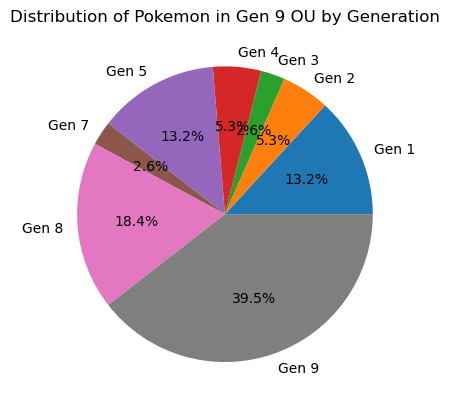

In [193]:
gen_counts = ou_df["Generation"].value_counts().sort_index()
labels = [f"Gen {g}" for g in gen_counts.index]

plt.pie(gen_counts.values, labels=labels, autopct="%1.1f%%")
plt.title("Distribution of Pokemon in Gen 9 OU by Generation")

Perhaps unsurprisingly, Gen 9 has the most Pokemon in it's OU generation. Between all the paradoxes and monsters like Gholdengo, this is fairly expected. What is surprising is absolutely no Pokemon from Gen 6.

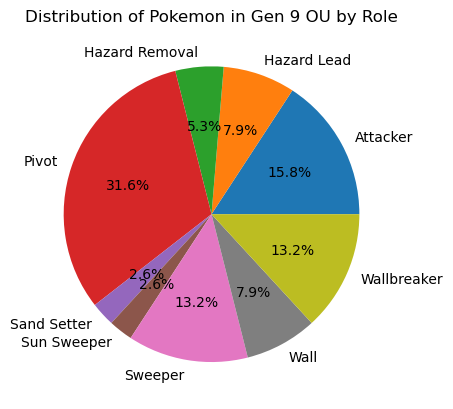

In [194]:
role_counts = ou_df["Role"].value_counts().sort_index()

plt.pie(role_counts.values, labels=role_counts.index, autopct="%1.1f%%")
plt.title("Distribution of Pokemon in Gen 9 OU by Role")
plt.show()

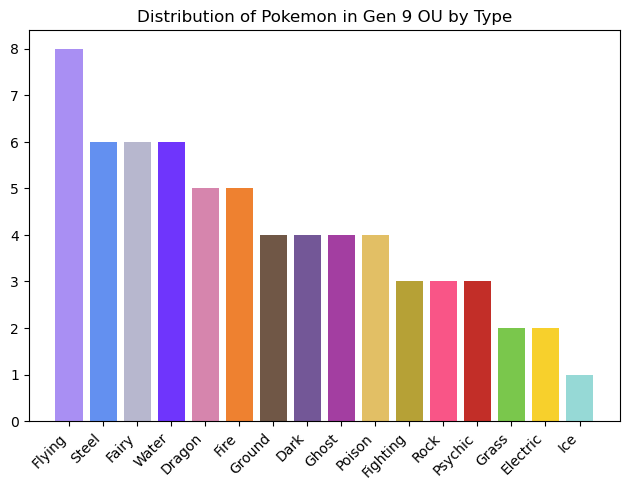

In [195]:
#type plot

type_colors = [
    "#A98FF3",  # Flying
    "#6390F0",  # Water
    "#B7B7CE",  # Steel
    "#6F35FC",  # Dragon
    "#D685AD",  # Fairy
    "#EE8130",  # Fire
    "#705746",  # Dark
    "#735797",  # Ghost
    "#A33EA1",  # Poison
    "#E2BF65",  # Ground
    "#B6A136",  # Rock
    "#F95587",  # Psychic
    "#C22E28",  # Fighting
    "#7AC74C",  # Grass
    "#F7D02C",  # Electric
    "#96D9D6",  # Ice
]
plt.bar(type_counts.index, type_counts.values, color=type_colors)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.title("Distribution of Pokemon in Gen 9 OU by Type")
plt.show()



There are absolutely ZERO normal types in Gen 9 OU.

First version of the team recommender will just be a basic heuristics recommendation system.

In [196]:

def team_recommender_basic(favorite_pokemon, df):
    required_roles = {"Hazard Removal", "Hazard Lead", "Wallbreaker", "Pivot", "Sweeper", "Attacker"}
    sand_setters = {"Hippowdon", "Tyranitar"}
    sand_sweepers = {"Excadrill"}

    rain_setters = {"Pelipper", "Politoed"}
    rain_sweepers = {"Barraskewda", "Kingdra", "Basculegion"}

    sun_setters = {"Torkoal", "Ninetales"}
    sun_sweepers = {"Walking Wake", "Venusaur", "Lilligant-Hisui"}
    roles_covered = set()
    types_covered = set()
    team = []
    team_set = set()

    #HELPERS
    def get_row(mon):
        row = df[df["Pokemon"] == mon]
        if row.empty:
            return None
        return row.iloc[0]

    def extract_roles(row):
        r = set()
        role = row.get("Role", None)
        if role is not None and str(role).lower() != "nan":
            r.add(str(role))
        return r
    
    def extract_types(row):
        t = set()
        t1 = row.get("Type 1", None)
        t2 = row.get("Type 2", None)
        if t1 is not None and str(t1).lower() != "nan":
            t.add(str(t1))
        if t2 is not None and str(t2).lower() != "nan":
            t.add(str(t2))
        t.discard(None)
        t.discard("")
        return t
    
    def candidate_scoring(row, roles_covered, types_covered):
        score = 0
        candidate_roles = extract_roles(row)
        candidate_types = extract_types(row)


        if len((required_roles - roles_covered) & candidate_roles) > 0:
            score += 5
        if len(candidate_roles - roles_covered) > 0:
            score += 2
        score += 2 * len(candidate_types - types_covered)
        if "Usage" in row.index:
            try:
                score += 0.05 * float(row["Usage"])
            except:
                pass
        return score, candidate_roles, candidate_types
    
    seed_pokemon = get_row(favorite_pokemon)
    if seed_pokemon is None:
        raise ValueError(f"{favorite_pokemon} not found in the dataset")
    
    team.append(favorite_pokemon)
    team_set.add(favorite_pokemon)

    seed_roles = extract_roles(seed_pokemon)
    seed_types = extract_types(seed_pokemon)
    roles_covered |= seed_roles
    types_covered |= seed_types

    while len(team) < 6:
        best_pokemon = None
        best_score = float('-inf')
        best_types = set()
        best_roles = set()

        need_sand_sweeper = (len(team_set & sand_setters) > 0) and (len(team_set & sand_sweepers) == 0)
        need_rain_sweeper = (len(team_set & rain_setters) > 0) and (len(team_set & rain_sweepers) <= 1)
        need_sun_sweeper = (len(team_set & sun_setters) > 0) and (len(team_set & sun_sweepers) <= 1)

        need_sand_setter = (len(team_set & sand_setters) == 0) and (len(team_set & sand_sweepers) > 0)
        need_rain_setter = (len(team_set & rain_setters) == 0) and (len(team_set & rain_sweepers) > 0)
        need_sun_setter = (len(team_set & sun_setters) == 0) and (len(team_set & sun_sweepers) > 0)


        for _, row in df.iterrows():
            pokemon = row["Pokemon"]
            if pokemon in team_set:
                continue
            if need_sand_sweeper and pokemon not in sand_sweepers:
                continue
            if need_sun_sweeper and pokemon not in sun_sweepers:
                continue
            if need_rain_sweeper and pokemon not in rain_sweepers:
                continue
            if need_sand_setter and pokemon not in sand_setters:
                continue
            if need_sun_setter and pokemon not in sun_setters:
                continue
            if need_rain_setter and pokemon not in rain_setters:
                continue

            score, candidate_roles, candidate_types = candidate_scoring(row, roles_covered, types_covered)
            if score > best_score:
                best_score = score
                best_pokemon = pokemon
                best_roles = candidate_roles
                best_types = candidate_types

            if best_pokemon is None:
                break
            
        team.append(best_pokemon)
        team_set.add(best_pokemon)
        roles_covered |= best_roles
        types_covered |= best_types
    return team











In [202]:
team = team_recommender_basic("Pawmot", with_roles)
team

['Pawmot',
 'Kingambit',
 'Dragapult',
 'Slowking-Galar',
 'Araquanid',
 'Great Tusk']